# Phase 4 — Analysis and Results

Consolidates the results from Phases 1–3 into the figures and tables used in the paper. No training — reads saved predictions and results JSONs only. Outputs go to `QCRI-CV/phase4/`.

---
# Section 1 — Environment
No GPU is required; this notebook reads saved predictions and produces figures and text.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q pycocotools matplotlib pandas

In [ ]:
import os, json, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
print('Imports ready')

Imports ready


---
# Section 2 — Configuration and results
Paths to the three phases' outputs, and the prediction files produced by their evaluation cells. The results files are merged into a single dictionary used throughout.

In [ ]:
BASE = '/content/drive/MyDrive/QCRI-CV'
P1, P2, P3 = f'{BASE}/phase1', f'{BASE}/phase2', f'{BASE}/phase3'
ROOT = f'{BASE}/phase4'
FIGS = f'{ROOT}/figures'
os.makedirs(FIGS, exist_ok=True)

VME_TEST_ANN  = f'{P1}/annotations/vme/test.json'
VME_IMGS      = f'{BASE}/VME_CDSI_datasets/satellite_images'

# prediction files written by each phase's evaluation cells
PREDS = {
    'baseline':          f'{P1}/results/preds/vme_test_epoch24.json',
    'oracle':            f'{P1}/results/preds/oracle_vme_test_epoch24.json',
    'oracle_sft':        f'{P1}/results/preds/oracle_sft_vme_test_epoch24.json',
    'gdino':             f'{P2}/preds/vme_gdino_car.json',
    'self_training':     f'{P3}/results/preds/selftrain_baseline_vme_test.json',
    'foundation_guided': f'{P3}/results/preds/foundation_guided_vme_test.json',
}

def merge_results():
    out = {}
    for p in [f'{P1}/results/phase1_results.json', f'{P2}/results/phase2_results.json',
              f'{P3}/results/phase3_results.json']:
        if os.path.exists(p):
            out.update(json.load(open(p)))
    return out

R = merge_results()
print('Loaded result keys:', len(R))
for k in sorted(R): print(' ', k)

Loaded result keys: 18
  baseline_pd_h
  baseline_vme_test_epoch24
  baseline_xview_test_epoch24
  foundation_guided_pd_h
  foundation_guided_vme_test
  foundation_guided_xview_test
  gdino_pd_h
  gdino_prompt_ablation
  gdino_pseudo_labels
  gdino_vme_test_best_prompt
  gdino_xview_test
  oracle_sft_vme_test_epoch24
  oracle_vme_test_epoch24
  pseudo_label_stats
  pseudo_threshold_selection
  selftrain_baseline_pd_h
  selftrain_baseline_vme_test
  selftrain_baseline_xview_test


---
# Section 3 — Main results table
The central table of the paper: target-domain (VME) accuracy for every method, from the zero-shot foundation model through the adapted detectors to the fully-supervised oracle.

In [ ]:
def g(key, field, default=float('nan')):
    return R.get(key, {}).get(field, default)

rows = [
    ('Grounding DINO (zero-shot)',            g('gdino_vme_test_best_prompt', 'mAP50'), g('gdino_vme_test_best_prompt', 'mAP'), 'no target training'),
    ('TOOD source-only (xView->VME)',         g('baseline_vme_test_epoch24', 'mAP50'),  g('baseline_vme_test_epoch24', 'mAP'),  'baseline'),
    ('TOOD + self-training',                  g('selftrain_baseline_vme_test', 'mAP50'),g('selftrain_baseline_vme_test', 'mAP'),'source pseudo-labels'),
    ('TOOD + foundation-guided self-training',g('foundation_guided_vme_test', 'mAP50'), g('foundation_guided_vme_test', 'mAP'), 'fused pseudo-labels (ours)'),
    ('TOOD oracle (standard)',                g('oracle_vme_test_epoch24', 'mAP50'),    g('oracle_vme_test_epoch24', 'mAP'),    'VME labels, upper bound'),
    ('TOOD oracle (slicing-aided)',           g('oracle_sft_vme_test_epoch24', 'mAP50'),g('oracle_sft_vme_test_epoch24', 'mAP'),'VME labels, upper bound'),
]
main_tbl = pd.DataFrame(rows, columns=['Method', 'mAP50', 'mAP', 'Notes'])
main_tbl['mAP50'] = main_tbl['mAP50'].round(1)
main_tbl['mAP'] = main_tbl['mAP'].round(1)
print(main_tbl.to_string(index=False))

base = g('baseline_vme_test_epoch24', 'mAP50')
st   = g('selftrain_baseline_vme_test', 'mAP50')
fg   = g('foundation_guided_vme_test', 'mAP50')
print(f'\nSelf-training gain over baseline : {st - base:+.1f} mAP50')
print(f'Foundation guidance over self-tr.: {fg - st:+.1f} mAP50')

                                Method  mAP50  mAP                      Notes
            Grounding DINO (zero-shot)   14.7  4.5         no target training
         TOOD source-only (xView->VME)   38.2 13.4                   baseline
                  TOOD + self-training   40.0 13.8       source pseudo-labels
TOOD + foundation-guided self-training   39.9 13.8 fused pseudo-labels (ours)
                TOOD oracle (standard)   55.6 23.2    VME labels, upper bound
           TOOD oracle (slicing-aided)   57.6 25.0    VME labels, upper bound

Self-training gain over baseline : +1.8 mAP50
Foundation guidance over self-tr.: -0.1 mAP50


# Section 4 — Cross-domain robustness
In-domain (xView) vs. out-of-distribution (VME) comparison using the RWDS Performance Drop and Harmonic Mean metrics. The adapted detectors show negative PD — this reflects source-domain forgetting, not robustness, and is reported as such.

In [ ]:
def pd_h(idd, ood):
    return 100 * (idd - ood) / idd, 2 * ood * idd / (ood + idd)

rob_rows = []
for name, idk, oodk in [
    ('TOOD source-only',           'baseline_xview_test_epoch24',     'baseline_vme_test_epoch24'),
    ('Grounding DINO (zero-shot)', 'gdino_xview_test',                'gdino_vme_test_best_prompt'),
    ('TOOD + self-training',       'selftrain_baseline_xview_test',   'selftrain_baseline_vme_test'),
    ('TOOD + foundation-guided',   'foundation_guided_xview_test',    'foundation_guided_vme_test'),
]:
    idd, ood = g(idk, 'mAP50'), g(oodk, 'mAP50')
    pdv, hv = pd_h(idd, ood)
    rob_rows.append((name, round(idd, 1), round(ood, 1), round(pdv, 1), round(hv, 1)))

rob_tbl = pd.DataFrame(rob_rows, columns=['Method', 'xView (ID)', 'VME (OOD)', 'PD (%)', 'H'])
print(rob_tbl.to_string(index=False))
print('\nLower PD = more robust to the domain shift. Negative PD for the adapted detectors')
print('reflects source-domain forgetting (OOD now exceeds the degraded ID accuracy).')

                    Method  xView (ID)  VME (OOD)  PD (%)    H
          TOOD source-only        58.8       38.2    34.9 46.3
Grounding DINO (zero-shot)        15.9       14.7     7.8 15.3
      TOOD + self-training        18.5       40.0  -116.5 25.3
  TOOD + foundation-guided        18.7       39.9  -113.7 25.5

Lower PD = more robust to the domain shift. Negative PD for the adapted detectors
reflects source-domain forgetting (OOD now exceeds the degraded ID accuracy).


---
# Section 5 — Qualitative comparison
Predictions of the source-only baseline, the self-trained detector, and the oracle on representative VME test images, with ground truth for reference. Boxes are drawn at a fixed confidence threshold. This figure makes the quantitative gaps concrete: where the adapted model recovers cars the baseline misses, and where the oracle's supervision still finds more.

loading annotations into memory...
Done (t=1.12s)
creating index...
index created!


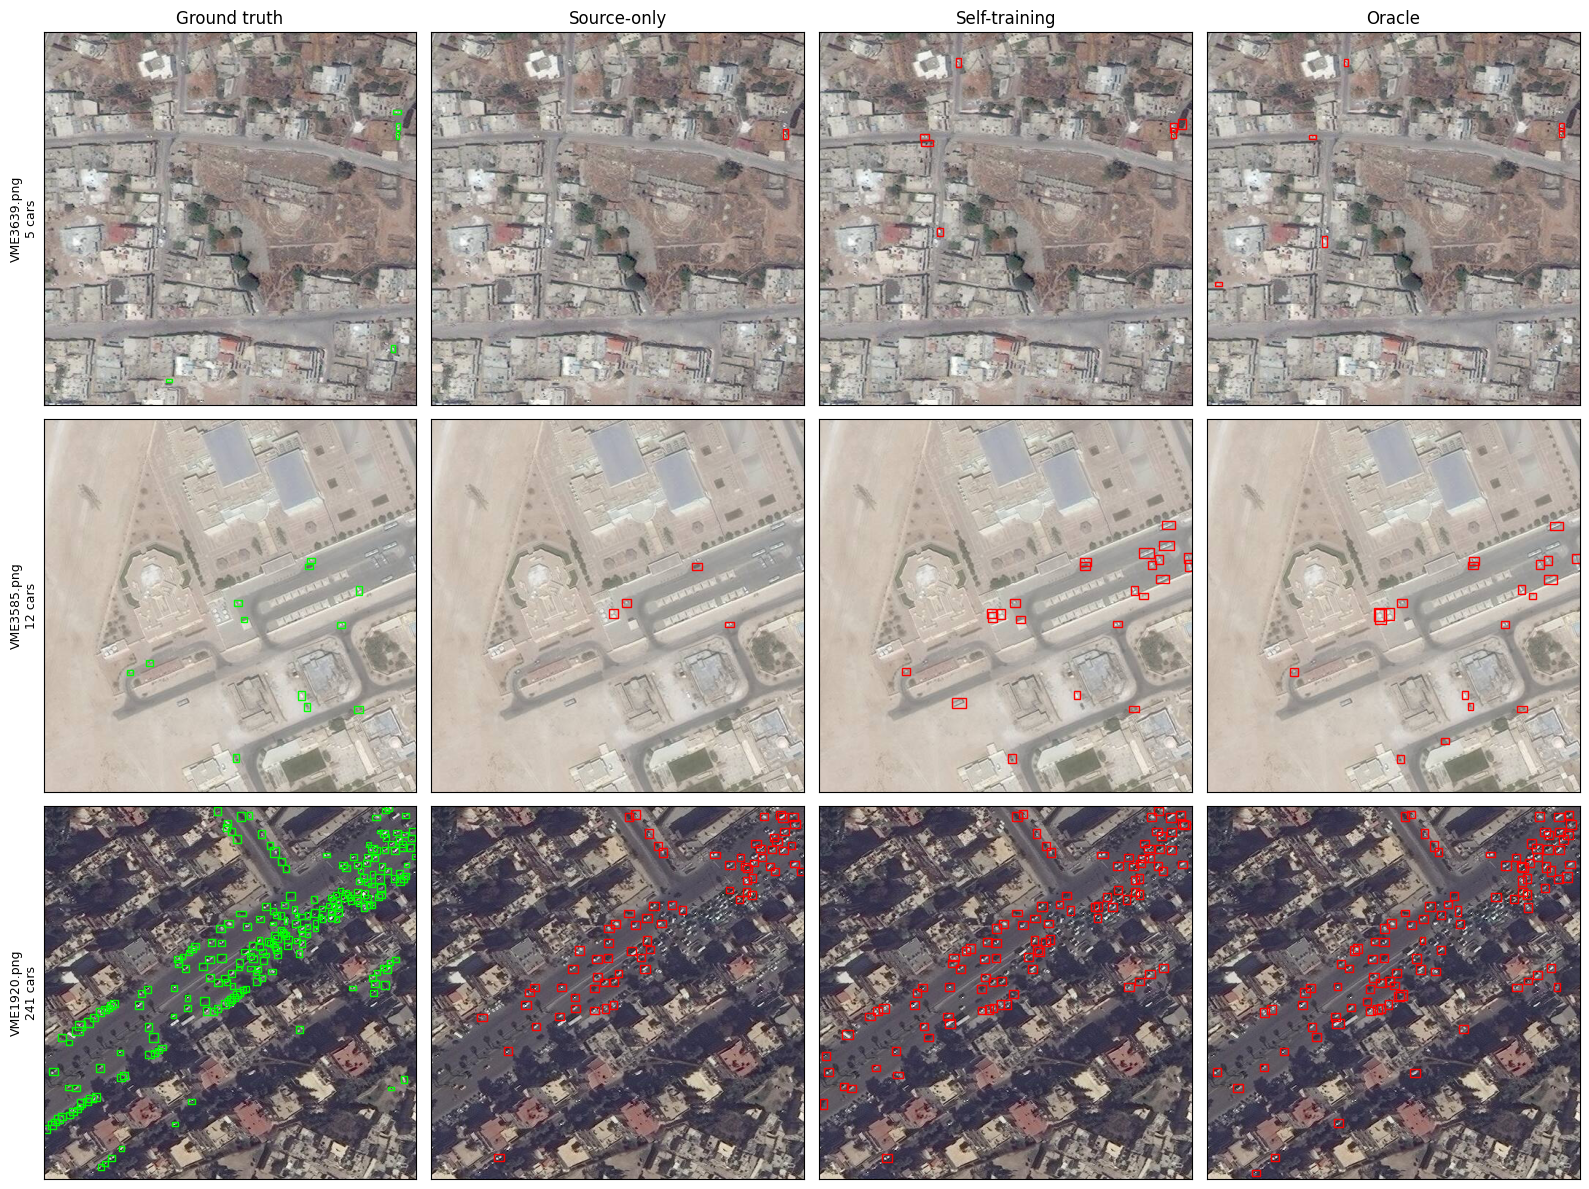

Saved qualitative_comparison.png / .pdf


In [ ]:
CONF = 0.3
coco = COCO(VME_TEST_ANN)

def load_preds_by_img(path, conf=CONF):
    d = defaultdict(list)
    if not os.path.exists(path):
        print('missing', path); return d
    for p in json.load(open(path)):
        if p['score'] >= conf:
            d[p['image_id']].append(p['bbox'])
    return d

pred_sets = {
    'Ground truth':       {iid: [a['bbox'] for a in coco.loadAnns(coco.getAnnIds(imgIds=iid))] for iid in coco.getImgIds()},
    'Source-only':        load_preds_by_img(PREDS['baseline']),
    'Self-training':      load_preds_by_img(PREDS['self_training']),
    'Oracle':             load_preds_by_img(PREDS['oracle']),
}

# pick three test images spanning low / medium / high car density
ids_by_density = sorted(coco.getImgIds(), key=lambda i: len(coco.getAnnIds(imgIds=i)))
picks = [ids_by_density[len(ids_by_density)//4],
         ids_by_density[len(ids_by_density)//2],
         ids_by_density[-1]]

import cv2
cols = list(pred_sets.keys())
fig, axes = plt.subplots(len(picks), len(cols), figsize=(4 * len(cols), 4 * len(picks)))
for r, iid in enumerate(picks):
    info = coco.loadImgs(iid)[0]
    im = cv2.cvtColor(cv2.imread(os.path.join(VME_IMGS, info['file_name'])), cv2.COLOR_BGR2RGB)
    for c, name in enumerate(cols):
        ax = axes[r, c]
        ax.imshow(im); ax.set_xticks([]); ax.set_yticks([])
        color = 'lime' if name == 'Ground truth' else 'red'
        boxes = pred_sets[name].get(iid, [])
        for x, y, w, h in boxes:
            ax.add_patch(patches.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=1))
        if r == 0:
            ax.set_title(name, fontsize=12)
        if c == 0:
            ax.set_ylabel(f"{info['file_name']}\n{len(pred_sets['Ground truth'][iid])} cars", fontsize=9)
plt.tight_layout()
for ext in ['png', 'pdf']:
    plt.savefig(f'{FIGS}/qualitative_comparison.{ext}', dpi=180, bbox_inches='tight')
plt.show()
print('Saved qualitative_comparison.png / .pdf')

# Section 6 — Error decomposition
Predictions matched to ground truth at IoU ≥ 0.5, split into true positives, localisation errors, background false positives, and missed cars. Shows whether the self-training gain comes from finding more cars (recall) or fewer false alarms (precision).

In [ ]:
def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    lt = np.maximum(a[:, None, :2], b[None, :, :2])
    rb = np.minimum(a[:, None, 2:], b[None, :, 2:])
    wh = np.clip(rb - lt, 0, None)
    inter = wh[..., 0] * wh[..., 1]
    return inter / (area_a[:, None] + area_b[None, :] - inter + 1e-9)

def decompose(pred_path, conf=CONF, iou_tp=0.5, iou_loc=0.1):
    by_img = defaultdict(list)
    for p in json.load(open(pred_path)):
        if p['score'] >= conf:
            x, y, w, h = p['bbox']
            by_img[p['image_id']].append((p['score'], [x, y, x + w, y + h]))
    tp = loc = bg = 0; n_gt = 0
    for iid in coco.getImgIds():
        gts = coco.loadAnns(coco.getAnnIds(imgIds=iid))
        gt = np.array([[a['bbox'][0], a['bbox'][1], a['bbox'][0] + a['bbox'][2], a['bbox'][1] + a['bbox'][3]] for a in gts]) if gts else np.zeros((0, 4))
        n_gt += len(gt)
        dets = sorted(by_img.get(iid, []), key=lambda z: -z[0])
        if not dets:
            continue
        boxes = np.array([d[1] for d in dets])
        iou = iou_matrix(boxes, gt)
        matched = set()
        for i in range(len(boxes)):
            j = int(np.argmax(iou[i])) if gt.shape[0] else -1
            best = iou[i, j] if j >= 0 else 0.0
            if best >= iou_tp and j not in matched:
                tp += 1; matched.add(j)
            elif best >= iou_loc:
                loc += 1
            else:
                bg += 1
    miss = n_gt - tp
    n_pred = tp + loc + bg
    prec = tp / (n_pred + 1e-9); rec = tp / (n_gt + 1e-9)
    return dict(TP=tp, Loc=loc, Bkg=bg, Miss=miss, precision=round(prec, 3), recall=round(rec, 3))

err_rows = []
for name, key in [('Source-only', 'baseline'), ('Self-training', 'self_training'),
                  ('Foundation-guided', 'foundation_guided'), ('Oracle', 'oracle')]:
    d = decompose(PREDS[key]); d['Method'] = name; err_rows.append(d)
err_tbl = pd.DataFrame(err_rows)[['Method', 'TP', 'Loc', 'Bkg', 'Miss', 'precision', 'recall']]
print(f'Error decomposition at confidence >= {CONF}, IoU(TP) >= 0.5\n')
print(err_tbl.to_string(index=False))
print(f'\nTotal ground-truth cars in VME test: {len(coco.getAnnIds())}')

Error decomposition at confidence >= 0.3, IoU(TP) >= 0.5

           Method    TP  Loc  Bkg  Miss  precision  recall
      Source-only  6780 1367  854 19678      0.753   0.256
    Self-training 12717 5399 6207 13741      0.523   0.481
Foundation-guided 12754 5401 6533 13704      0.517   0.482
           Oracle 15369 3121 5556 11089      0.639   0.581

Total ground-truth cars in VME test: 26458


### 6.1 — Error composition figure

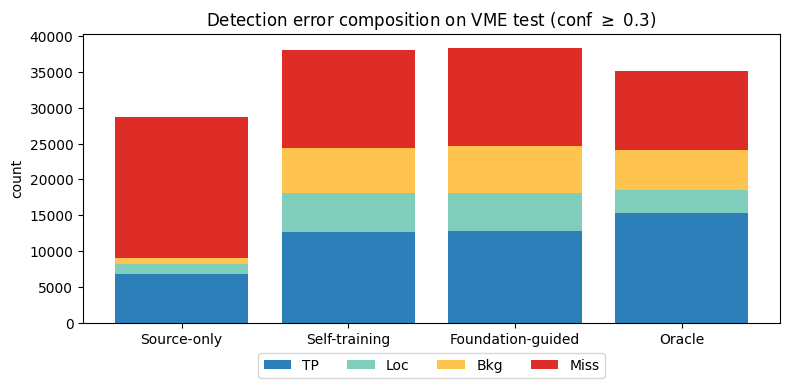

Saved error_composition.png / .pdf


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
methods = err_tbl['Method'].tolist()
bottoms = np.zeros(len(methods))
for comp, color in [('TP', '#2c7fb8'), ('Loc', '#7fcdbb'), ('Bkg', '#fec44f'), ('Miss', '#de2d26')]:
    vals = err_tbl[comp].values
    ax.bar(methods, vals, bottom=bottoms, label=comp, color=color)
    bottoms += vals
ax.set_ylabel('count'); ax.set_title(f'Detection error composition on VME test (conf $\\geq$ {CONF})')
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
for ext in ['png', 'pdf']:
    plt.savefig(f'{FIGS}/error_composition.{ext}', dpi=180, bbox_inches='tight')
plt.show()
print('Saved error_composition.png / .pdf')

# Section 7 — Prompt ablation
Grounding DINO zero-shot accuracy on VME across the five prompts tested in Phase 2. The plain word "car" wins; adding aerial or satellite context hurts.

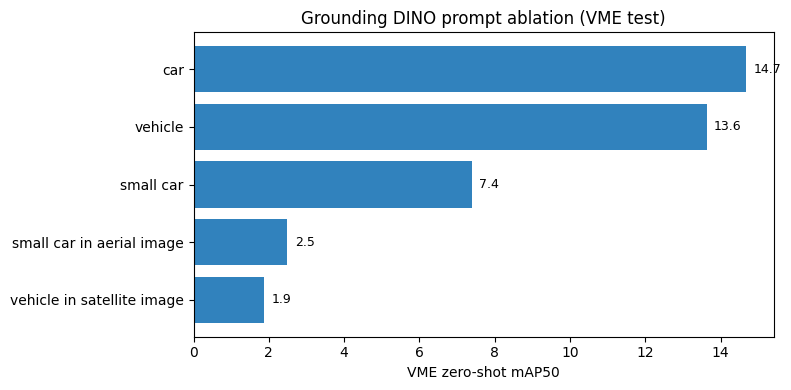

                    prompt  mAP50    mAP  n_dets
                       car  14.68 -100.0   76601
                   vehicle  13.63 -100.0  168172
                 small car   7.39 -100.0  125127
 small car in aerial image   2.49 -100.0   91956
vehicle in satellite image   1.88 -100.0   90561


In [ ]:
abl = R.get('gdino_prompt_ablation', {}).get('table', [])
if abl:
    adf = pd.DataFrame(abl).sort_values('mAP50', ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(adf['prompt'], adf['mAP50'], color='#3182bd')
    ax.set_xlabel('VME zero-shot mAP50'); ax.invert_yaxis()
    ax.set_title('Grounding DINO prompt ablation (VME test)')
    for i, (v, p) in enumerate(zip(adf['mAP50'], adf['prompt'])):
        ax.text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)
    plt.tight_layout()
    for ext in ['png', 'pdf']:
        plt.savefig(f'{FIGS}/prompt_ablation.{ext}', dpi=180, bbox_inches='tight')
    plt.show()
    print(adf.to_string(index=False))
else:
    print('Prompt ablation not found in results')

# Section 8 — LaTeX tables
The three main tables formatted for direct inclusion in the paper.

### 8.1 — LaTeX tables

In [ ]:
def fmt(v): return f'{v:.1f}'

# Table 1: main results
t1 = [r'\begin{table}[t]', r'\centering',
      r'\caption{Vehicle detection on the VME (Middle Eastern) car test set. mAP and mAP$_{50}$ in \%. Oracle rows use VME labels and bound the achievable accuracy.}',
      r'\label{tab:main}', r'\begin{tabular}{lcc}', r'\toprule',
      r'Method & mAP$_{50}$ & mAP \\', r'\midrule']
for _, row in main_tbl.iterrows():
    t1.append(f"{row['Method']} & {fmt(row['mAP50'])} & {fmt(row['mAP'])} \\\\")
t1 += [r'\bottomrule', r'\end{tabular}', r'\end{table}']

# Table 2: robustness
t2 = [r'\begin{table}[t]', r'\centering',
      r'\caption{Cross-domain robustness. ID: xView car test; OOD: VME car test (mAP$_{50}$, \%). PD: Performance Drop; H: Harmonic Mean. Negative PD reflects source-domain forgetting after adaptation.}',
      r'\label{tab:robust}', r'\begin{tabular}{lcccc}', r'\toprule',
      r'Method & ID & OOD & PD (\%) & H \\', r'\midrule']
for _, row in rob_tbl.iterrows():
    t2.append(f"{row['Method']} & {fmt(row['xView (ID)'])} & {fmt(row['VME (OOD)'])} & {fmt(row['PD (%)'])} & {fmt(row['H'])} \\\\")
t2 += [r'\bottomrule', r'\end{tabular}', r'\end{table}']

# Table 3: error decomposition
t3 = [r'\begin{table}[t]', r'\centering',
      r'\caption{Error decomposition on VME test (confidence $\geq$ 0.3, IoU$_{TP}\geq$0.5). TP: true positives; Loc: localisation errors; Bkg: background false positives; Miss: undetected ground-truth cars.}',
      r'\label{tab:errors}', r'\begin{tabular}{lcccccc}', r'\toprule',
      r'Method & TP & Loc & Bkg & Miss & P & R \\', r'\midrule']
for _, row in err_tbl.iterrows():
    t3.append(f"{row['Method']} & {row['TP']} & {row['Loc']} & {row['Bkg']} & {row['Miss']} & {row['precision']:.2f} & {row['recall']:.2f} \\\\")
t3 += [r'\bottomrule', r'\end{tabular}', r'\end{table}']

latex_tables = '\n'.join(t1) + '\n\n' + '\n'.join(t2) + '\n\n' + '\n'.join(t3)
with open(f'{ROOT}/tables.tex', 'w') as f:
    f.write(latex_tables)
print(latex_tables)

\begin{table}[t]
\centering
\caption{Vehicle detection on the VME (Middle Eastern) car test set. mAP and mAP$_{50}$ in \%. Oracle rows use VME labels and bound the achievable accuracy.}
\label{tab:main}
\begin{tabular}{lcc}
\toprule
Method & mAP$_{50}$ & mAP \\
\midrule
Grounding DINO (zero-shot) & 14.7 & 4.5 \\
TOOD source-only (xView->VME) & 38.2 & 13.4 \\
TOOD + self-training & 40.0 & 13.8 \\
TOOD + foundation-guided self-training & 39.9 & 13.8 \\
TOOD oracle (standard) & 55.6 & 23.2 \\
TOOD oracle (slicing-aided) & 57.6 & 25.0 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[t]
\centering
\caption{Cross-domain robustness. ID: xView car test; OOD: VME car test (mAP$_{50}$, \%). PD: Performance Drop; H: Harmonic Mean. Negative PD reflects source-domain forgetting after adaptation.}
\label{tab:robust}
\begin{tabular}{lcccc}
\toprule
Method & ID & OOD & PD (\%) & H \\
\midrule
TOOD source-only & 58.8 & 38.2 & 34.9 & 46.3 \\
Grounding DINO (zero-shot) & 15.9 & 14.7 & 7.8 & 15.3 \

### 8.3 — Output summary

In [ ]:
import os
print('Phase 4 outputs in', ROOT, ':\n')
for root, _, files in os.walk(ROOT):
    for f in sorted(files):
        p = os.path.join(root, f)
        print(f'  {os.path.relpath(p, ROOT):40} {os.path.getsize(p)//1024:>5} KB')

Phase 4 outputs in /content/drive/MyDrive/QCRI-CV/phase4 :

  paper_draft.md                               9 KB
  tables.tex                                   1 KB
  figures/error_composition.pdf               15 KB
  figures/error_composition.png               47 KB
  figures/prompt_ablation.pdf                 16 KB
  figures/prompt_ablation.png                 45 KB
  figures/qualitative_comparison.pdf        7391 KB
  figures/qualitative_comparison.png        2498 KB
